### Regresion lineal Scikitlearn

In [371]:
import pandas as pd
import sqlite3
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from math import sqrt
from sklearn import preprocessing
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import numpy as np

In [372]:
## Creacion de la base de datos
cnx = sqlite3.connect('DataSets/database.sqlite')

In [373]:
df = pd.read_sql_query("SELECT * FROM Player_Attributes", cnx)

In [374]:
df.head(10)

,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
5,6,189615,155782,2016-04-21 00:00:00,74.0,76.0,left,high,medium,80.0,...,66.0,59.0,76.0,75.0,78.0,14.0,7.0,9.0,9.0,12.0
6,7,189615,155782,2016-04-07 00:00:00,74.0,76.0,left,high,medium,80.0,...,66.0,59.0,76.0,75.0,78.0,14.0,7.0,9.0,9.0,12.0
7,8,189615,155782,2016-01-07 00:00:00,73.0,75.0,left,high,medium,79.0,...,65.0,59.0,76.0,75.0,78.0,14.0,7.0,9.0,9.0,12.0
8,9,189615,155782,2015-12-24 00:00:00,73.0,75.0,left,high,medium,79.0,...,65.0,59.0,76.0,75.0,78.0,14.0,7.0,9.0,9.0,12.0
9,10,189615,155782,2015-12-17 00:00:00,73.0,75.0,left,high,medium,79.0,...,65.0,59.0,76.0,75.0,78.0,14.0,7.0,9.0,9.0,12.0


In [375]:
df.shape

(183978, 42)

In [376]:
df.columns

Index(['id', 'player_fifa_api_id', 'player_api_id', 'date', 'overall_rating',
       'potential', 'preferred_foot', 'attacking_work_rate',
       'defensive_work_rate', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning',
       'gk_reflexes'],
      dtype='object')

In [377]:
### De todas las columnas determinaremos cuales se usaran como features para alimentar al modelo


In [378]:
features = ['potential','crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning',
       'gk_reflexes']

In [379]:
### Seleccionamos Traget
target = ['overall_rating']

In [380]:
### Limpiar los datos eliminando filas con datos nan
x = pd.get_dummies(x)
df = df.dropna(axis=1, thresh=0.7*len(x))

In [381]:
### Separamos las caracterisiticas en X, y el target en Y
x = df[features]
y = df[target]

### Mostrar el contenido de una fila del conjunto X


In [382]:
x.iloc[3]

potential             65.0
crossing              48.0
finishing             43.0
heading_accuracy      70.0
short_passing         60.0
volleys               43.0
dribbling             50.0
curve                 44.0
free_kick_accuracy    38.0
long_passing          63.0
ball_control          48.0
acceleration          60.0
sprint_speed          64.0
agility               59.0
reactions             46.0
balance               65.0
shot_power            54.0
jumping               58.0
stamina               54.0
strength              76.0
long_shots            34.0
aggression            62.0
interceptions         40.0
positioning           44.0
vision                53.0
penalties             47.0
marking               62.0
standing_tackle       63.0
sliding_tackle        66.0
gk_diving              5.0
gk_handling           10.0
gk_kicking             9.0
gk_positioning         7.0
gk_reflexes            7.0
Name: 3, dtype: float64

In [383]:
x.head()

,potential,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,long_passing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,71.0,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,71.0,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,66.0,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,65.0,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,65.0,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0


In [384]:
y.head()

,overall_rating
0,67.0
1,67.0
2,62.0
3,61.0
4,61.0


### Muestreo de los valores la feature reactions para cada jugador

In [385]:
x['reactions']
x = x.fillna(x.mean())
y = y.fillna(y.mean())

### Imprimir la relacion existente las caracterisitca "Reaction" y "Over reaction"

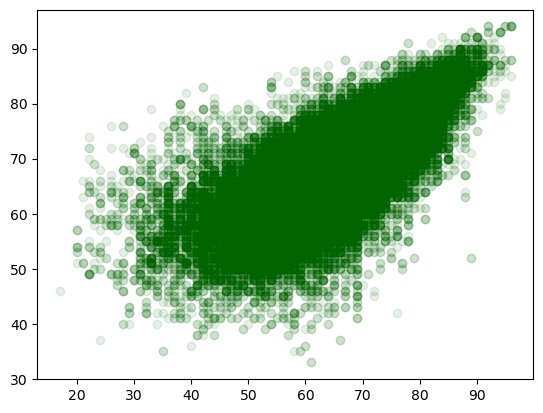

In [386]:
plt.scatter(x['reactions'], y, color= 'darkgreen', label = 'Datos', alpha=.1)

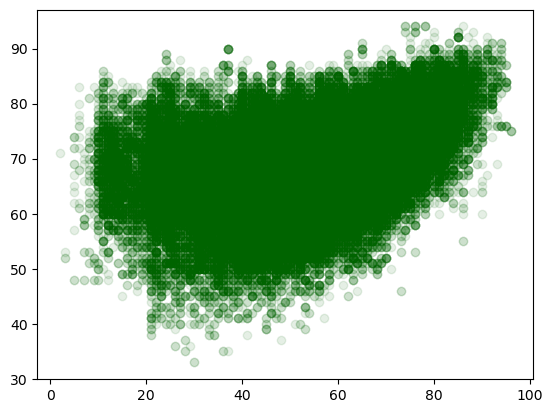

In [387]:
plt.scatter(x['penalties'], y, color= 'darkgreen', label = 'Datos', alpha=.1)

### Separacion de los datos en training  y test Datasets

In [388]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.25, random_state = 420)


### Utilizar un escalado standar
para que los datos de cada feature se acople a un rango y se eviten los sesgos de un feature con valores muy altos que puedan influir de mas en el modelo

In [389]:
scale = preprocessing.StandardScaler()

### Entrenar con los datos escalado

In [390]:
scale.fit(x_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [391]:
x_train = scale.fit_transform(x_train)

# imprimir los nuevos valores minimo y maximo de las features de entrenamiento

In [392]:
x_train.min()

np.float64(-5.373482437269455)

In [393]:
x_train.max()

np.float64(4.9816220907201565)

### Creamos una instancia del modelo de regresion lineal


In [394]:
regresor = LinearRegression()

### Ajustar modelo

In [395]:
regresor.fit(x_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Realizar una prediccion usando el conjunto de datos de prueba (Test set)

In [396]:
# Escalar los valores de prueba para que conicidan con los de entrenamiento
x_test = scale.transform(x_test)

# Hacer una prediccion del valor de salida

In [397]:
y_prediccion = regresor.predict(x_test)


In [398]:
# la diferencia que hay entre los valores de salida predichos vs los valores de salida reales
y_result = y_prediccion - y_test
y_result

,overall_rating
25009,-2.502436
85702,-1.494371
12964,-3.458654
129935,-2.038479
109441,1.388300
...,...
84215,0.366865
173398,2.727637
85893,-1.212410
3950,-3.783625


### Calcular la raiz cuadrad del error cuadratico medio

In [399]:
RMSE = sqrt(mean_squared_error(y_true = y_test, y_pred = y_prediccion))
print(RMSE)

2.809939419789706


### Mostrar la presicion que obtuvo el modelo al predecir con los valores de prueba

In [400]:
regresor.score(x_train,y_train)

0.8420287164871378

In [401]:
### mostar cada valor de cada w que se aplico a cada feature
regresor.coef_

array([[ 2.49992124,  0.37785322,  0.23433187,  1.14694079,  0.72554292,
         0.06161011, -0.21304453,  0.18985837,  0.24911056,  0.09200531,
         2.03646854,  0.09908165,  0.09455575, -0.11541125,  1.92008446,
         0.10656958,  0.27670125,  0.17412829, -0.06150737,  0.72773381,
        -0.24809409,  0.32468229,  0.24012347, -0.19016496, -0.05344932,
         0.22568074,  0.69575749,  0.04832356, -0.5968467 ,  2.78156677,
         0.48243469, -0.70272665,  0.87571385,  0.41929869]])

In [402]:
regresor.intercept_

array([68.59213678])

### Modificacion eb la presicion del modelo 
### De acuerdo lo declarado anteriormente para la division de los datos de prueba se realizan modificaciones en los datos:
### "x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.33, random_state = 324)"

### Al reducir el numero en test_size= y cambiarlo por numero menores podremos tener mas datos de entrenamiento y dejar menos datas de prueba con los que se podra llegar a mas fiabilidad

### Al cambiar los valores de "test_size= 0.15, random_state = 5042" se obtiene como resultado "0.8409585921256664"
### Al realizar otra prueba y cambiar los valores de "test_size= 0.35, random_state = 5000" se obtiene como resultado "0.8432492189403259" obteniendo un valor un poco mas elevado
### Al realizar otra prueba y cambiar los valores de "test_size= 0.02, random_state = 200" se obtiene como resultado "0.8484696371323274" obteniendo un valor un poco mas elevado
### Al realizar otra prueba y cambiar los valores de "test_size= 0.02, random_state = 210" se obtiene como resultado "0.8510810542763801" obteniendo un valor un poco mas elevado

### Se cambio el test_size para que tome un 2% teniendo mas datos de entrenamiento pero muy pocos de test solo significaria que ese split fue más favorable pero no mas preciso y
### aunque haya mostrado mejor resultado no indica que el modelo sea mejor ya que se esta evaluando con muy pocos datos.

### Se modifico la linea "df = df.dropna(axis=1, thresh=0.7*len(x))" para tratar de mejorar la presicion eliminando datos na y "y = y.fillna(y.mean())" 